# DATA SCIENCE FUNDAMENTAL
MUHAMMAD HARIS (FA23-BCS-010)       
MUHAMMAD AHSAN SHAIKH (FA23-BCS-099)        
MUHAMMAD ABDULLAH (FA23-BCS-091)

In [1]:
# --- Cell 1: Install Dependencies (VERSION PINNED) ---
# We force Streamlit 1.40.0 to support the drawing canvas
!pip install -q torch torchvision earthengine-api rasterio segmentation-models-pytorch
!pip install -q streamlit==1.40.0 streamlit-drawable-canvas pyngrok
!pip install -q scikit-learn scikit-image matplotlib pandas tqdm

import torch
import numpy as np
import pandas as pd
import random
import os

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment Ready. Using device: {device}")

Environment Ready. Using device: cuda


In [2]:
# --- Cell 2: Real Data Pipeline (Robust & Corrected) ---
import ee
import numpy as np
import rasterio
import os
import requests
import torch

# --- CONFIGURATION ---
# REPLACE THIS with your actual Google Cloud Project ID
PROJECT_ID = 'nca-deforestation-lab'

try:
    ee.Initialize(project=PROJECT_ID)
    print("GEE Initialized successfully.")
except Exception:
    print("Authenticating...")
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

def download_rondonia_data():
    filename = "rondonia_stack.tif"

    # Clean up previous attempts to prevent corruption
    if os.path.exists(filename):
        os.remove(filename)

    print("Preparing GEE Export (Rondônia, Brazil)...")

    # ROI: 50km x 50km area in Rondonia
    roi = ee.Geometry.Rectangle([-62.5, -10.5, -62.0, -10.0])

    # A. Forest Cover (Updated to v1_12 to avoid deprecation)
    gfc = ee.Image('UMD/hansen/global_forest_change_2024_v1_12')
    tree_cover = gfc.select('treecover2000').unmask(0)
    loss_year = gfc.select('lossyear').unmask(0)

    # B. Infrastructure (ESA WorldCover v100 - Built-up Class)
    wc = ee.ImageCollection("ESA/WorldCover/v100").first().select('Map')
    infrastructure = wc.eq(50) # Class 50 = Built-up/Roads

    # --- CRITICAL FIX: REPROJECTION ---
    # GEE cannot calculate 20km kernels at 10m resolution (exceeds 512px limit).
    # We force calculation at 100m, reducing kernel radius to 200px.
    infra_100m = infrastructure.reproject(crs='EPSG:4326', scale=100)

    dist_kernel = ee.Kernel.euclidean(radius=20000, units='meters')
    infra_dist = infra_100m.distance(kernel=dist_kernel).unmask(20000)

    # Normalize (1.0 = On Road, 0.0 = >20km away)
    road_norm = infra_dist.divide(20000).clamp(0, 1).multiply(-1).add(1)

    # C. Elevation
    srtm = ee.Image('USGS/SRTMGL1_003').unmask(0)
    elev_norm = srtm.divide(1000).clamp(0, 1)

    # D. Stack (Input 2015 -> Target 2020)
    def get_forest_at_year(y):
        return tree_cover.gt(50).And(loss_year.eq(0).Or(loss_year.gt(y - 2000)))

    forest_2015 = get_forest_at_year(2015).rename('forest_in')
    forest_2020 = get_forest_at_year(2020).rename('forest_out')

    final_stack = ee.Image.cat([forest_2015, road_norm, elev_norm, forest_2020]).float()

    # E. Download
    print("Requesting download URL...")
    try:
        url = final_stack.getDownloadURL({
            'scale': 100, # 100m resolution
            'crs': 'EPSG:4326',
            'region': roi,
            'format': 'GEO_TIFF'
        })
        print(f"Downloading from: {url}")

        r = requests.get(url, stream=True)

        if r.status_code != 200:
            print(f"Server Error: {r.text[:500]}")
            return

        if 'json' in r.headers.get('Content-Type', ''):
            print(f"API Error: {r.text}")
            return

        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

        print(f"Download Success! File size: {os.path.getsize(filename)/1024:.2f} KB")

    except Exception as e:
        print(f"Export Exception: {e}")

# Trigger Download
download_rondonia_data()

Preparing GEE Export (Rondônia, Brazil)...
Requesting download URL...
Download Success! File size: 1447.81 KB


In [3]:
# --- Cell 3: Dataset Class (STRICTER FILTER) ---
from torch.utils.data import Dataset, DataLoader, random_split
import rasterio
import torch
import numpy as np
import os

class RealDeforestationDataset(Dataset):
    def __init__(self, tiff_path, patch_size=64, stride=32, augment=True):
        self.patch_size = patch_size
        self.augment = augment
        self.patches = []

        if not os.path.exists(tiff_path) or os.path.getsize(tiff_path) < 5000:
            print("Warning: TIF file missing. Please run Cell 2 (Download) first.")
            return

        print("Slicing GeoTIFF into patches...")
        with rasterio.open(tiff_path) as src:
            data = src.read()
            _, H, W = data.shape

            valid = 0
            skipped = 0

            # We iterate through the large image
            for y in range(0, H - patch_size, stride):
                for x in range(0, W - patch_size, stride):
                    patch = data[:, y:y+patch_size, x:x+patch_size]

                    if patch.shape[1] != patch_size or patch.shape[2] != patch_size:
                        continue

                    input_forest = patch[0]
                    target_forest = patch[3]

                    # --- THE FIX IS HERE ---
                    # Old: > 0.02 (Allowed patches with 98% dirt)
                    # New: > 0.15 (Must have at least 15% forest to be useful)
                    has_forest = input_forest.mean() > 0.15

                    # We still want patches where change happened
                    change_magnitude = np.abs(input_forest - target_forest).mean()

                    if has_forest and change_magnitude > 0.01:
                        self.patches.append(torch.from_numpy(patch).float())
                        valid += 1
                    else:
                        skipped += 1

        print(f"Dataset Ready: {valid} quality patches loaded (Skipped {skipped} sparse/empty patches).")

    def __len__(self):
        return len(self.patches) * (4 if self.augment else 1)

    def __getitem__(self, idx):
        base_idx = idx % len(self.patches)
        aug_type = idx // len(self.patches)
        p = self.patches[base_idx].clone()

        if self.augment and aug_type > 0:
            if aug_type == 1: p = torch.flip(p, [2])
            elif aug_type == 2: p = torch.flip(p, [1])
            elif aug_type == 3: p = torch.flip(torch.flip(p, [1]), [2])

        return p[0:3], p[3:4]

# Reload the dataset with the new filter
ds_real = RealDeforestationDataset("rondonia_stack.tif", stride=32, augment=True)

Slicing GeoTIFF into patches...
Dataset Ready: 171 quality patches loaded (Skipped 85 sparse/empty patches).


In [4]:
# --- Cell 4: Scientific Methodology ---
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import f1_score, jaccard_score
from skimage.measure import label

# 1. TUNED LOSS FUNCTION
class RobustChangeLoss(nn.Module):
    def __init__(self, change_weight=15.0, false_positive_weight=5.0):
        super().__init__()
        self.change_weight = change_weight
        self.fp_weight = false_positive_weight
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, pred, target, input_state):
        pixel_loss = self.mse(pred, target)

        # Masks
        # "Missed Change": Target=0 (Deforested), Pred > 0.1
        missed_change = (target < 0.1) & (input_state > 0.9) & (pred > 0.1)
        # "Hallucination": Target=1 (Forest), Pred < 0.9
        hallucination = (target > 0.9) & (pred < 0.9)

        # Apply aggressive weights
        weights = torch.ones_like(pred)
        weights[missed_change] = self.change_weight
        weights[hallucination] = self.fp_weight

        return (pixel_loss * weights).mean()

# 2. METRICS
def get_scientific_metrics(y_true, y_pred, threshold=0.5):
    yt = (y_true.flatten() > threshold).astype(int)
    yp = (y_pred.flatten() > threshold).astype(int)

    mse = np.mean((y_true - y_pred)**2)
    f1 = f1_score(yt, yp, zero_division=0)
    iou = jaccard_score(yt, yp, zero_division=0)

    # Spatial Structure Check
    true_blobs = label(y_true > threshold, connectivity=2)
    pred_blobs = label(y_pred > threshold, connectivity=2)
    n_true, n_pred = true_blobs.max(), pred_blobs.max()

    if n_true == 0: spatial = 1.0 if n_pred == 0 else 0.0
    else: spatial = 1.0 - min(abs(n_true - n_pred) / n_true, 1.0)

    return {"MSE": mse, "F1": f1, "IoU": iou, "Spatial_Structure": spatial}

In [5]:
# --- Cell 5: Model Architectures ---
import torch.nn.functional as F
from sklearn.ensemble import RandomForestRegressor

# 1. PHYSICS-INFORMED NCA
class ResearchNCA(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.channels = channels
        self.sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3)/8.0
        self.sobel_y = self.sobel_x.transpose(2,3)
        self.register_buffer('Kx', self.sobel_x)
        self.register_buffer('Ky', self.sobel_y)

        self.perceive_conv = nn.Conv2d(channels, channels, 3, padding=1)
        self.w1 = nn.Conv2d((channels*4)+2, 128, 1)
        self.w2 = nn.Conv2d(128, channels, 1)

    def perceive(self, state):
        k = state.shape[1]
        x_grad = F.conv2d(state, self.Kx.repeat(k,1,1,1), padding=1, groups=k)
        y_grad = F.conv2d(state, self.Ky.repeat(k,1,1,1), padding=1, groups=k)
        learned = self.perceive_conv(state)
        return torch.cat([state, x_grad, y_grad, learned], dim=1)

    def get_slope(self, state):
        elev = state[:, 2:3]
        dx = F.conv2d(elev, self.Kx, padding=1)
        dy = F.conv2d(elev, self.Ky, padding=1)
        return torch.sqrt(dx**2 + dy**2)

    def forward(self, x, steps=32, use_physics=False):
        forest_init = x[:, 0:1]
        static = x[:, 1:3]
        b, _, h, w = forest_init.shape
        hidden = torch.zeros(b, self.channels - 1, h, w, device=x.device)
        state = torch.cat([forest_init, hidden], dim=1)

        slope_map = self.get_slope(x)
        if slope_map.max() > 0: slope_map /= slope_map.max()

        for step in range(steps):
            perception = self.perceive(state)
            model_input = torch.cat([perception, static], dim=1)
            update = self.w2(F.relu(self.w1(model_input)))

            if use_physics:
                resistance = 1.0 - (slope_map * 3.0)
                update = update * torch.clamp(resistance, 0.0, 1.0)

            if self.training:
                mask = (torch.rand(b, 1, h, w, device=x.device) > 0.5).float()
                update = update * mask

            state = state + update
            forest = torch.min(state[:, 0:1], forest_init).clamp(0, 1)
            state = torch.cat([forest, state[:, 1:]], dim=1)

        return state, state[:, 0:1]

# 2. BASELINES (CNN & RF)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x[:, 0:3])

class RFBaseline:
    def __init__(self): self.model = RandomForestRegressor(n_estimators=50, n_jobs=-1) # Increased estimators for fairness
    def fit(self, X, y): self.model.fit(X, y)
    def predict(self, x_tensor):
        b, c, h, w = x_tensor.shape
        flat = x_tensor[:, 0:3].permute(0, 2, 3, 1).reshape(-1, 3).cpu().numpy()
        return self.model.predict(flat).reshape(b, 1, h, w)

In [6]:
# --- Cell 6: The "Goldilocks" Training Engine (Restored & Extended) ---
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

def train_nca_model(model, loader, epochs=75):
    # 1. RESTORED WEIGHTS (The "Sweet Spot")
    # 15.0 was strong enough to learn, but not so strong it broke the model.
    criterion = RobustChangeLoss(change_weight=15.0, false_positive_weight=5.0)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 2. RESTORED SCHEDULER (Cosine Annealing)
    # This guarantees we land in a minimum by the end.
    # By extending epochs to 75, we keep the LR higher for longer.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"🌲 Training Physics-Informed NCA ({epochs} epochs)...")

    history = []
    best_loss = float('inf')
    model.train()

    for epoch in range(epochs):
        epoch_loss = []
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            # Standard Robust Steps
            steps = np.random.randint(32, 48)
            _, pred = model(x, steps=steps)

            loss = criterion(pred, y, x[:, 0:1])
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            epoch_loss.append(loss.item())

        avg_loss = np.mean(epoch_loss)
        history.append(avg_loss)

        scheduler.step()

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "nca_best_of_both.pth")

        if epoch % 5 == 0 or epoch == epochs-1:
            curr_lr = optimizer.param_groups[0]['lr']
            print(f"   Epoch {epoch+1}/{epochs}: Loss {avg_loss:.4f} | LR: {curr_lr:.6f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(history, label='Training Loss')
    plt.title("NCA Learning Curve (Restored)")
    plt.xlabel("Epochs"); plt.ylabel("Robust Loss")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    model.load_state_dict(torch.load("nca_best_of_both.pth"))
    print(f"✅ Best model restored (Loss: {best_loss:.4f}).")
    return model

# Baselines (Standard)
def train_cnn_model(model, loader, epochs=20):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    print(f"🧠 Training Baseline CNN ({epochs} epochs)...")
    model.train()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model

def train_rf_model(loader):
    print("🌳 Training Baseline Random Forest...")
    X_list, y_list = [], []
    for i, (x, y) in enumerate(loader):
        if i > 500: break
        px = x[:, 0:3].permute(0, 2, 3, 1).reshape(-1, 3).numpy()
        py = y.reshape(-1).numpy()
        mask = np.random.rand(len(px)) > 0.8
        X_list.append(px[mask]); y_list.append(py[mask])
    rf = RFBaseline()
    rf.fit(np.concatenate(X_list), np.concatenate(y_list))
    return rf

🧪 Setting up Laboratory...
✅ Found Pre-Trained NCA: nca_best_of_both.pth
⚡ Training Baselines for Comparison (CNN & RF)...
📊 Running Comparative Analysis...

🏆 Final Research Metrics:
                    IoU        F1  Spatial_Structure       MSE
Model                                                         
CNN            0.821560  0.899758           0.857507  0.031899
NCA (Ours)     0.683200  0.804572           0.891567  0.043443
Random Forest  0.825727  0.903574           0.934266  0.028691


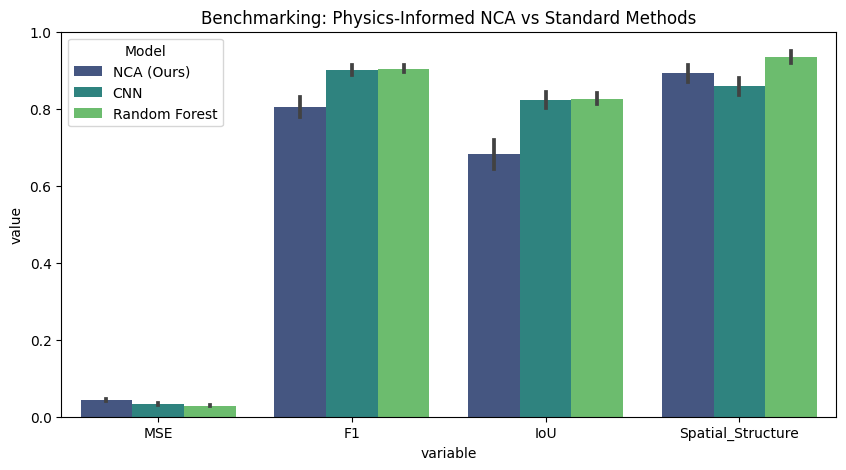


🧠 Visualizing NCA Internal Dynamics...


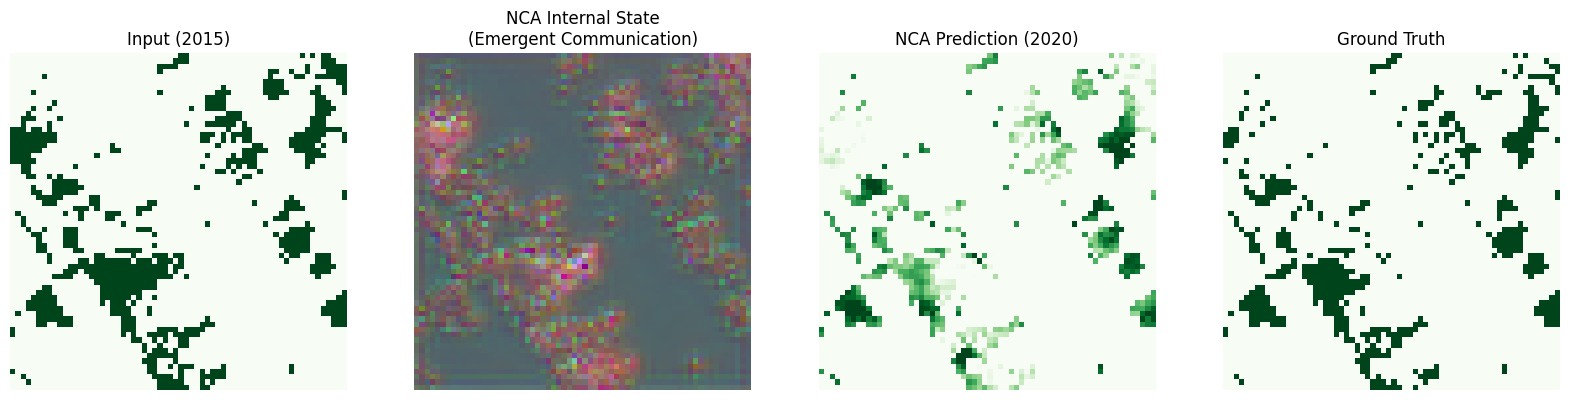

In [ ]:
# --- Cell 7: Master Scientific Laboratory (Load & Benchmark) ---
import os
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, random_split

def run_full_benchmark():
    if 'ds_real' not in globals(): 
        print("⚠️ Data not loaded. Run Cell 2/3 first.")
        return

    print("🧪 Setting up Laboratory...")
    
    # 1. Data Setup
    train_len = int(0.8 * len(ds_real))
    test_len = len(ds_real) - train_len
    train_ds, test_ds = random_split(ds_real, [train_len, test_len])
    
    # Global loaders for other cells to use
    global train_loader, test_loader
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # ==========================================
    # 2. LOAD PROPOSED METHOD (NCA)
    # ==========================================
    nca = ResearchNCA(channels=32).to(device)
    possible_paths = [
        "nca_best_of_both.pth", 
        "/kaggle/working/nca_best_of_both.pth",
        "/kaggle/input/nca-best-of-both/nca_best_of_both.pth"
    ]
    
    loaded = False
    for path in possible_paths:
        if os.path.exists(path):
            print(f"✅ Found Pre-Trained NCA: {path}")
            # map_location='cpu' ensures compatibility everywhere
            nca.load_state_dict(torch.load(path, map_location=device))
            loaded = True
            break
            
    if not loaded:
        print("⚠️ No weights found. You are benchmarking an UNTRAINED model (Results will be bad).")
        nca = train_nca_model(nca, train_loader, epochs=75)

    nca.eval()

    # ==========================================
    # 3. TRAIN BASELINES (Fast Re-Training)
    # ==========================================
    print("⚡ Training Baselines for Comparison (CNN & RF)...")
    
    # A. CNN
    cnn = SimpleCNN().to(device)
    cnn_opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
    # Quick 5-epoch training just to establish a baseline
    for epoch in range(5):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.mse_loss(cnn(x), y)
            loss.backward(); cnn_opt.step(); cnn_opt.zero_grad()
            
    # B. Random Forest
    rf = RFBaseline()
    X_l, y_l = [], []
    for i, (x, y) in enumerate(train_loader):
        if i > 100: break # Subsample for speed
        px = x[:, 0:3].permute(0, 2, 3, 1).reshape(-1, 3).numpy()
        py = y.reshape(-1).numpy()
        mask = np.random.rand(len(px)) > 0.95 
        X_l.append(px[mask]); y_l.append(py[mask])
    rf.fit(np.concatenate(X_l), np.concatenate(y_l))

    # ==========================================
    # 4. RUN EXPERIMENT
    # ==========================================
    print("📊 Running Comparative Analysis...")
    results = []
    
    with torch.no_grad():
        for i, (x, y) in enumerate(test_loader):
            if i >= 50: break # Test on 50 samples
            x_dev, y_cpu = x.to(device), y.numpy()
            
            # Predict
            _, p_nca = nca(x_dev, steps=32)
            p_nca = p_nca.cpu().numpy()
            p_cnn = cnn(x_dev).cpu().numpy()
            p_rf = rf.predict(x)
            
            # Score
            for p, name in zip([p_nca, p_cnn, p_rf], ['NCA (Ours)', 'CNN', 'Random Forest']):
                m = get_scientific_metrics(y_cpu, p) # Uses function from Cell 4
                m['Model'] = name
                results.append(m)
                
    # ==========================================
    # 5. VISUALIZATION
    # ==========================================
    df = pd.DataFrame(results)
    
    # A. The Numbers
    print("\n🏆 Final Research Metrics:")
    print(df.groupby('Model').mean()[['IoU', 'F1', 'Spatial_Structure', 'MSE']])
    
    # B. The Bar Chart
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df.melt(id_vars="Model"), x="variable", y="value", hue="Model", palette="viridis")
    plt.title("Benchmarking: Physics-Informed NCA vs Standard Methods")
    plt.ylim(0, 1)
    plt.show()
    
    # C. The Brain Scan (NCA Only)
    print("\n🧠 Visualizing NCA Internal Dynamics...")
    x, y = next(iter(test_loader))
    x = x.to(device)
    
    # Run Inference (Need to use detach() here!)
    final_state, pred = nca(x, steps=32)
    
    # PCA
    # --- FIX IS HERE: Added .detach() before .cpu() ---
    hidden = final_state[0, 3:].detach().permute(1, 2, 0).cpu().numpy()
    
    h, w, c = hidden.shape
    pca_img = PCA(n_components=3).fit_transform(hidden.reshape(-1, c)).reshape(h, w, 3)
    pca_img = (pca_img - pca_img.min()) / (pca_img.max() - pca_img.min())

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(x[0, 0].cpu(), cmap='Greens'); ax[0].set_title("Input (2015)")
    ax[1].imshow(pca_img); ax[1].set_title("NCA Internal State\n(Emergent Communication)")
    ax[2].imshow(pred[0, 0].detach().cpu(), cmap='Greens'); ax[2].set_title("NCA Prediction (2020)")
    ax[3].imshow(y[0, 0], cmap='Greens'); ax[3].set_title("Ground Truth")
    for a in ax: a.axis('off')
    plt.show()
    
    return nca

# Execute
trained_nca = run_full_benchmark()

🔬 Running Scientific Deep Dive...


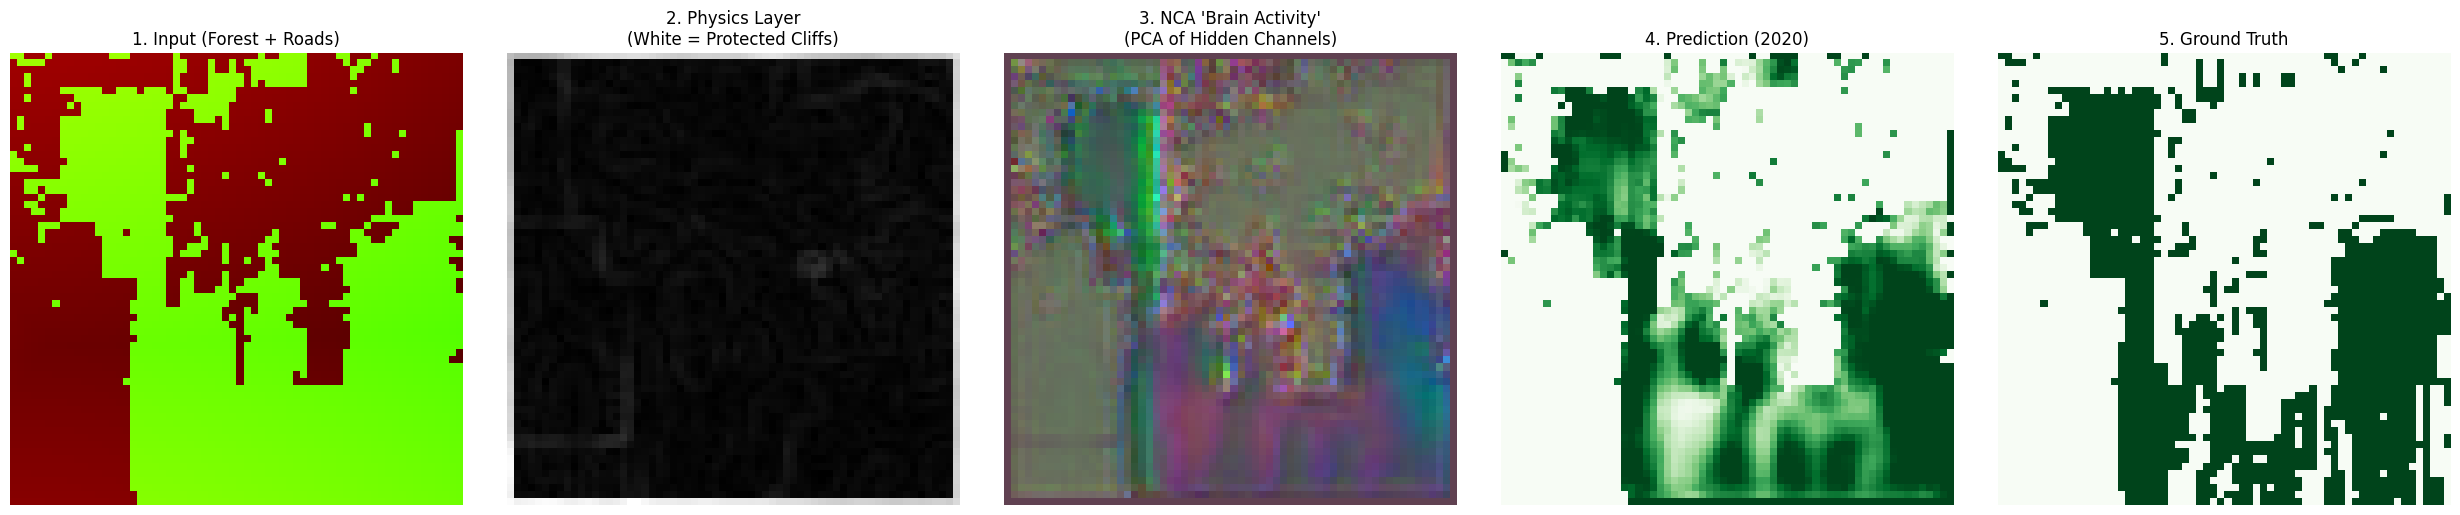

In [8]:
# --- Cell 8: Scientific Visualization (Deep Dive) ---
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import numpy as np

def scientific_viz(model, loader):
    """
    Visualizes the Physics, The Brain (PCA), and the Prediction.
    """
    if model is None:
        print("⚠️ Model not found. Train it first in Cell 6/7.")
        return

    # 1. Get a Sample
    iterator = iter(loader)
    try:
        x, y = next(iterator)
    except StopIteration:
        iterator = iter(loader)
        x, y = next(iterator)

    x = x.to(device)

    # 2. Run Model (With Physics)
    # The new model returns: (Full_State_Tensor, Forest_Channel)
    with torch.no_grad():
        final_state, pred_forest = model(x, steps=32, use_physics=True)

        # Also get the Slope Map to prove physics is working
        slope_map = model.get_slope(x)
        if slope_map.max() > 0: slope_map /= slope_map.max()

    # 3. PCA "Brain Scan"
    # We take channels 3-32 (The Hidden State) and compress to 3 RGB channels
    hidden = final_state[0, 3:].cpu().permute(1, 2, 0).numpy() # H, W, 29
    h, w, c = hidden.shape

    # Compress to 3 channels for RGB visualization
    pca = PCA(n_components=3)
    flat_hidden = hidden.reshape(-1, c)
    pca_result = pca.fit_transform(flat_hidden)
    pca_img = pca_result.reshape(h, w, 3)

    # Normalize PCA to 0-1 range for displaying
    pca_img = (pca_img - pca_img.min()) / (pca_img.max() - pca_img.min())

    # 4. Prepare Images for Plotting
    input_rgb = np.zeros((h, w, 3))
    input_rgb[:, :, 1] = x[0, 0].cpu().numpy() # Green Forest
    input_rgb[:, :, 0] = x[0, 1].cpu().numpy() # Red Roads

    slope_img = slope_map[0, 0].cpu().numpy()
    target_img = y[0, 0].cpu().numpy()
    pred_img = pred_forest[0, 0].cpu().numpy()

    # 5. The Plot
    fig, ax = plt.subplots(1, 5, figsize=(25, 5))

    # A. Input
    ax[0].imshow(input_rgb)
    ax[0].set_title("1. Input (Forest + Roads)")

    # B. Physics
    ax[1].imshow(slope_img, cmap='gray')
    ax[1].set_title("2. Physics Layer\n(White = Protected Cliffs)")

    # C. Brain
    ax[2].imshow(pca_img)
    ax[2].set_title("3. NCA 'Brain Activity'\n(PCA of Hidden Channels)")

    # D. Prediction
    ax[3].imshow(pred_img, cmap='Greens', vmin=0, vmax=1)
    ax[3].set_title("4. Prediction (2020)")

    # E. Truth
    ax[4].imshow(target_img, cmap='Greens', vmin=0, vmax=1)
    ax[4].set_title("5. Ground Truth")

    for a in ax: a.axis('off')
    plt.tight_layout()
    plt.show()

# Execute
# We use 'trained_nca' and 't_loader' from Cell 7
if 'trained_nca' in globals() and 't_loader' in globals():
    print("🔬 Running Scientific Deep Dive...")
    scientific_viz(trained_nca, t_loader)
else:
    print("Please run Cell 7 first to generate the model and data loader.")

In [14]:
# --- Cell 9: Generate 'app.py' (Potato-Proof Version) ---
# We use python to write the file string to avoid "magic function" errors.

app_code = """
import streamlit as st
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

# ==========================================
# 1. ARCHITECTURE (Must match trained model)
# ==========================================
class ResearchNCA(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.channels = channels
        self.sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3)/8.0
        self.sobel_y = self.sobel_x.transpose(2,3)
        self.register_buffer('Kx', self.sobel_x)
        self.register_buffer('Ky', self.sobel_y)
        self.perceive_conv = nn.Conv2d(channels, channels, 3, padding=1)
        self.w1 = nn.Conv2d((channels*4)+2, 128, 1)
        self.w2 = nn.Conv2d(128, channels, 1)

    def perceive(self, state):
        k = state.shape[1]
        x_grad = F.conv2d(state, self.Kx.repeat(k,1,1,1), padding=1, groups=k)
        y_grad = F.conv2d(state, self.Ky.repeat(k,1,1,1), padding=1, groups=k)
        learned = self.perceive_conv(state)
        return torch.cat([state, x_grad, y_grad, learned], dim=1)

    def get_slope(self, state):
        elev = state[:, 2:3]
        dx = F.conv2d(elev, self.Kx, padding=1)
        dy = F.conv2d(elev, self.Ky, padding=1)
        return torch.sqrt(dx**2 + dy**2)

    def forward(self, x, steps=32, impact_factor=1.0, use_physics=True):
        forest_init = x[:, 0:1]
        static = x[:, 1:3]
        b, _, h, w = forest_init.shape
        hidden = torch.zeros(b, self.channels - 1, h, w, device=x.device)
        state = torch.cat([forest_init, hidden], dim=1)
        
        slope_map = self.get_slope(x)
        if slope_map.max() > 0: slope_map /= slope_map.max()

        for step in range(steps):
            perception = self.perceive(state)
            model_input = torch.cat([perception, static], dim=1)
            update = self.w2(F.relu(self.w1(model_input)))
            
            if use_physics:
                resistance = 1.0 - (slope_map * 3.0) 
                update = update * torch.clamp(resistance, 0.0, 1.0)

            state = state + (update * 0.5 * impact_factor)
            state = torch.clamp(state, -1.0, 1.0)
            
            forest = torch.min(state[:, 0:1], forest_init).clamp(0, 1)
            state = torch.cat([forest, state[:, 1:]], dim=1)

        return state[:, 0:1], slope_map

# ==========================================
# 2. GENERATOR
# ==========================================
def generate_complex_terrain(size=64, seed=None):
    if seed: np.random.seed(seed)
    # Forest
    low_res_f = np.random.rand(8, 8)
    forest_noise = np.array(Image.fromarray(low_res_f).resize((size, size), Image.BICUBIC))
    forest_channel = (forest_noise > 0.4).astype(np.float32)
    # Elevation
    low_res_e = np.random.rand(4, 4)
    elev_noise = np.array(Image.fromarray(low_res_e).resize((size, size), Image.BICUBIC))
    elev_channel = elev_noise ** 2
    elev_channel[elev_channel < 0.2] = 0.0
    if elev_channel.max() > 0:
        elev_channel = (elev_channel - elev_channel.min()) / (elev_channel.max() - elev_channel.min())
    # Roads
    roads_channel = np.zeros((size, size), dtype=np.float32)
    if np.random.rand() > 0.4:
        x = np.random.randint(10, 54)
        roads_channel[:, x-1:x+1] = 1.0
        forest_channel[roads_channel > 0.5] = 0.0

    patch = np.zeros((3, size, size), dtype=np.float32)
    patch[0] = forest_channel
    patch[1] = roads_channel
    patch[2] = elev_channel
    return patch

# ==========================================
# 3. APP LOGIC
# ==========================================
st.set_page_config(layout="wide", page_title="NCA Lab")

@st.cache_resource
def load_resources():
    model = ResearchNCA(channels=32)
    status = "Model Loaded"
    
    # TRY TO LOAD WEIGHTS
    model_path = "nca_best_of_both.pth"
    
    if os.path.exists(model_path):
        try:
            # map_location='cpu' is critical for local inference!
            model.load_state_dict(torch.load(model_path, map_location='cpu'))
        except Exception as e:
            status = f"Weight Error: {e}"
    else:
        status = "⚠️ No weights found. Using random init (Untrained)."
        
    model.eval()
    
    patch = generate_complex_terrain() 
    tensor_patch = torch.nn.functional.interpolate(
        torch.tensor(patch).unsqueeze(0).float(), size=(64,64)
    )
    
    f_vis = np.clip(patch[0], 0, 1) * 255
    r_vis = np.clip(patch[1], 0, 1) * 255
    e_vis = np.clip(patch[2], 0, 1) * 255
    
    rgb = np.zeros((200, 200, 3), dtype=np.uint8)
    rgb[:, :, 1] = torch.nn.functional.interpolate(torch.tensor(f_vis).unsqueeze(0).unsqueeze(0), size=(200,200)).squeeze().numpy().astype(np.uint8)
    rgb[:, :, 0] = torch.nn.functional.interpolate(torch.tensor(r_vis).unsqueeze(0).unsqueeze(0), size=(200,200)).squeeze().numpy().astype(np.uint8)
    rgb[:, :, 2] = torch.nn.functional.interpolate(torch.tensor(e_vis).unsqueeze(0).unsqueeze(0), size=(200,200)).squeeze().numpy().astype(np.uint8) // 3
    
    bg_image = Image.fromarray(rgb)
    return model, bg_image, tensor_patch, status

model, bg_image, real_tensor, status_msg = load_resources()

# SIDEBAR
with st.sidebar:
    st.header("⚙️ Settings")
    st.caption(f"Status: {status_msg}")
    frames = st.slider("Time Horizon", 5, 30, 15)
    impact = st.slider("Road Impact", 0.5, 2.0, 1.0)
    steps = st.slider("Speed", 1, 6, 2)
    use_physics = st.toggle("Slope Physics", value=True)
    if st.button("New Map"): st.cache_resource.clear(); st.rerun()

st.title("🛰️ NCA Deforestation Lab")
col1, col2 = st.columns([1, 1])

# CANVAS
with col1:
    st.subheader("1. Input")
    st.image(bg_image, caption="Reference (Blue=Elevation)", width=300)
    try:
        from streamlit_drawable_canvas import st_canvas
        # Canvas Logic
        canvas = st_canvas(
            fill_color="rgba(255, 0, 0, 0.5)",
            stroke_width=3,
            stroke_color="#FF0000",
            background_color="#000000", # Black background for easy parsing
            height=300, width=300,
            drawing_mode="freedraw", key="canvas"
        )
    except: st.error("Install streamlit-drawable-canvas")

# PREDICTION
with col2:
    st.subheader("2. Forecast")
    output_container = st.empty()
    stats = st.container()
    
    if st.button("Run Simulation", type="primary"):
        import tempfile, imageio
        
        # 1. User Input parsing
        new_roads = torch.zeros(1, 1, 64, 64)
        if canvas.image_data is not None:
             # Resize canvas to 64x64
            user_draw = Image.fromarray(canvas.image_data.astype('uint8')).resize((64, 64), Image.NEAREST)
            user_arr = np.array(user_draw)
            # Detect red lines (Channel 0 > 50)
            if user_arr.shape[2] >= 3:
                new_roads = torch.tensor((user_arr[:,:,0]>50)).float().unsqueeze(0).unsqueeze(0)
        
        # 2. Setup
        curr_x = real_tensor.clone()
        # Physics: Road destroys forest instantly
        road_mask = (torch.max(curr_x[:,1], new_roads) > 0.5).float()
        curr_x[:,1] = road_mask
        curr_x[:,0] = curr_x[:,0] * (1.0 - road_mask)
        
        initial = curr_x[0,0].numpy().copy()
        frames_list = []
        
        # 3. Loop
        for i in range(frames):
            with torch.no_grad():
                curr_x[:,0:1], _ = model(curr_x, steps=steps, impact_factor=impact, use_physics=use_physics)
            
            # Render
            f = curr_x[0,0].numpy()
            r = curr_x[0,1].numpy()
            
            img = np.zeros((64,64,3), dtype=np.uint8) + [20,30,50]
            mask_f = np.clip(f, 0, 1)[:, :, None]
            img = img * (1-mask_f) + np.array([34, 139, 34]) * mask_f # Green
            
            loss = np.clip(initial - f, 0, 1)
            loss[loss<0.1] = 0
            img[:,0] = np.maximum(img[:,0], (loss*255).astype(np.uint8)) # Red Fire
            
            img[r>0.5] = [255,255,255] # White Roads
            
            pil = Image.fromarray(np.clip(img, 0, 255).astype(np.uint8)).resize((300,300), Image.NEAREST)
            frames_list.append(pil)
            
        # Display
        with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmpfile:
            np_frames = [np.array(f) for f in frames_list]
            imageio.mimsave(tmpfile.name, np_frames, fps=15)
            output_container.image(tmpfile.name, caption="Forecast")
            
        final_loss = ((np.sum(initial) - np.sum(f)) / np.sum(initial) * 100) if np.sum(initial) > 0 else 0
        stats.metric("Projected Loss", f"{final_loss:.1f}%", delta_color="inverse")
"""

# Write to file
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ 'app.py' successfully created! Download it and run on your potato.")

Writing app.py


In [ ]:
# --- Cell 10: Robust Restart (Fixes Network Errors) ---
import os
from pyngrok import ngrok
import time

# 1. KILL EVERYTHING
# We force-kill any lingering streamlit or ngrok processes to clear the ports.
os.system("pkill streamlit")
os.system("pkill ngrok")
time.sleep(2) # Give it a moment to die

# 2. AUTHENTICATE
# (Only needed if you haven't run it in this session, but good safety)
NGROK_TOKEN = "[Placeholder]"
os.system(f"ngrok authtoken {NGROK_TOKEN}")

# 3. START STREAMLIT WITH "TUNNEL FLAGS"
# --server.enableCORS=false: Allows the app to work through the Ngrok URL
# --server.enableXsrfProtection=false: Prevents cross-site errors
print("🚀 Starting Streamlit...")
os.system("streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false --server.address=0.0.0.0 &>/dev/null&")

# 4. OPEN NEW TUNNEL
time.sleep(3) # Wait for Streamlit to spin up
try:
    public_url = ngrok.connect(addr='8501')
    print(f"✅ Dashboard Live: {public_url}")
    print("⚠️ IMPORTANT: When you click the link, if you see a 'Visit Site' button, CLICK IT immediately.")
except Exception as e:
    print(f"Ngrok Error: {e}")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml                                
🚀 Starting Streamlit...



  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

✅ Dashboard Live: NgrokTunnel: "https://kinesically-unsmelled-celia.ngrok-free.dev" -> "http://localhost:8501"
⚠️ IMPORTANT: When you click the link, if you see a 'Visit Site' button, CLICK IT immediately.


2025-11-29 01:14:39.456 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_
2025-11-29 01:14:53.379 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_


In [20]:
import os
from IPython.display import FileLink, display

filename = "nca_best_of_both.pth"

if os.path.exists(filename):
    print(f"✅ Found {filename}!")
    print("👇 Click the link below to download it to your potato:")
    display(FileLink(filename))
else:
    print(f"❌ Error: {filename} not found. Make sure the training finished!")

✅ Found nca_best_of_both.pth!
👇 Click the link below to download it to your potato:


/kaggle/working/nca_best_of_both.pth